In [ ]:
%autoreload 2

In [1447]:
%reload_ext autoreload
import os, sys, random
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
from matplotlib import  rcParams
from fish import Gafftopsail
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
import utils, barcode
path = (r'C:/Data/Imaging\250912_overlap//fish13//')
rcParams['font.size'] = 12

In [1448]:
fish = Gafftopsail(path, filelist = ['stimulus', 'imaging'], sequence = 1)
fish.stimulus_df.stim_name = [str(s) for s in fish.stimulus_df.stim_name]

not smoothed
not smoothed
not smoothed
not smoothed
not smoothed


__EACH STIM__

In [1449]:
#axis 0: trial; axis 1: neuron; axis 2: frame
#from stationary start to duration + 20
f_pertrial_dict = barcode.get_pertrial_f(fish)

getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s
getting pertrial f stim duration + 20s


__Calculate the DSI of the neuron__

In [1450]:
dot_stim = None
stim_responses = barcode.get_grating_dsi(fish,f_pertrial_dict,baseline_s=7,response_s=10, dot_stim = dot_stim)

__barcoding 2: large response__

In [1451]:
barred_gratingneurons = barcode.select_gratingbarcode(fish, f_pertrial_dict, baseline_s = 7, response_s =10, perc_trial_threshold = 0.8)

selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 2
selection criteria: max >= baseline mean * 2


In [1452]:
barred_gratingneurons = barcode.sort_gratingneurons(fish, f_pertrial_dict, barred_gratingneurons)

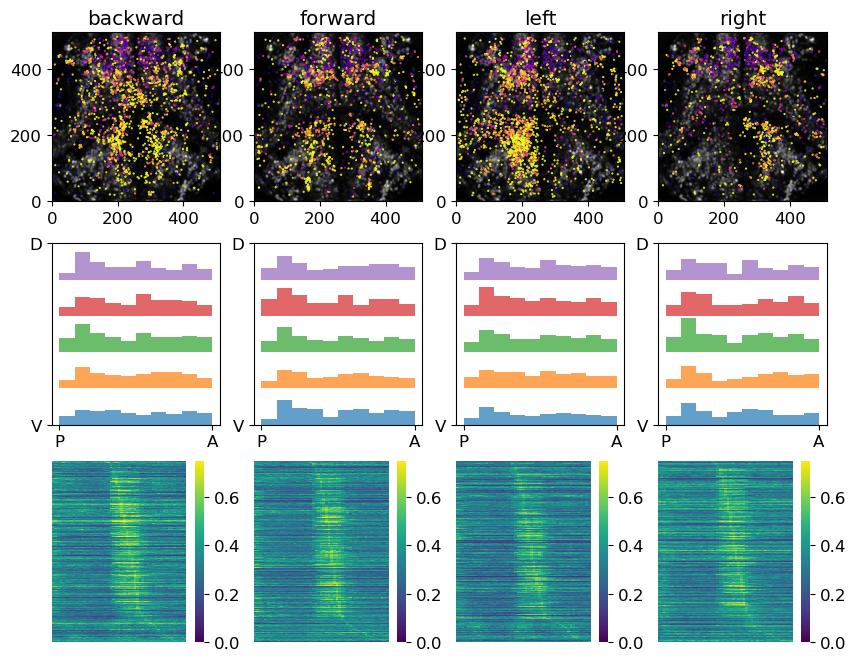

In [1442]:
fig = barcode.plot_gratingneurons(fish, f_pertrial_dict, barred_gratingneurons, stim_responses = stim_responses)
plt.show()
plt.close()

__rainbow plot__

In [1406]:
#combine barcoding and stim_responses
for stim, neurons in barred_gratingneurons.items():
    stim_responses[f'barred_{stim}'] = stim_responses.index.isin(neurons)

#save it
os.makedirs(os.path.join(fish.path, "analyze_results"), exist_ok=True)
if dot_stim is not None:
    stim_responses.to_csv(fish.path + f'//analyze_results//{dot_stim}grating_responses.csv')
else:
    stim_responses.to_csv(fish.path + f'//analyze_results//grating_responses.csv')

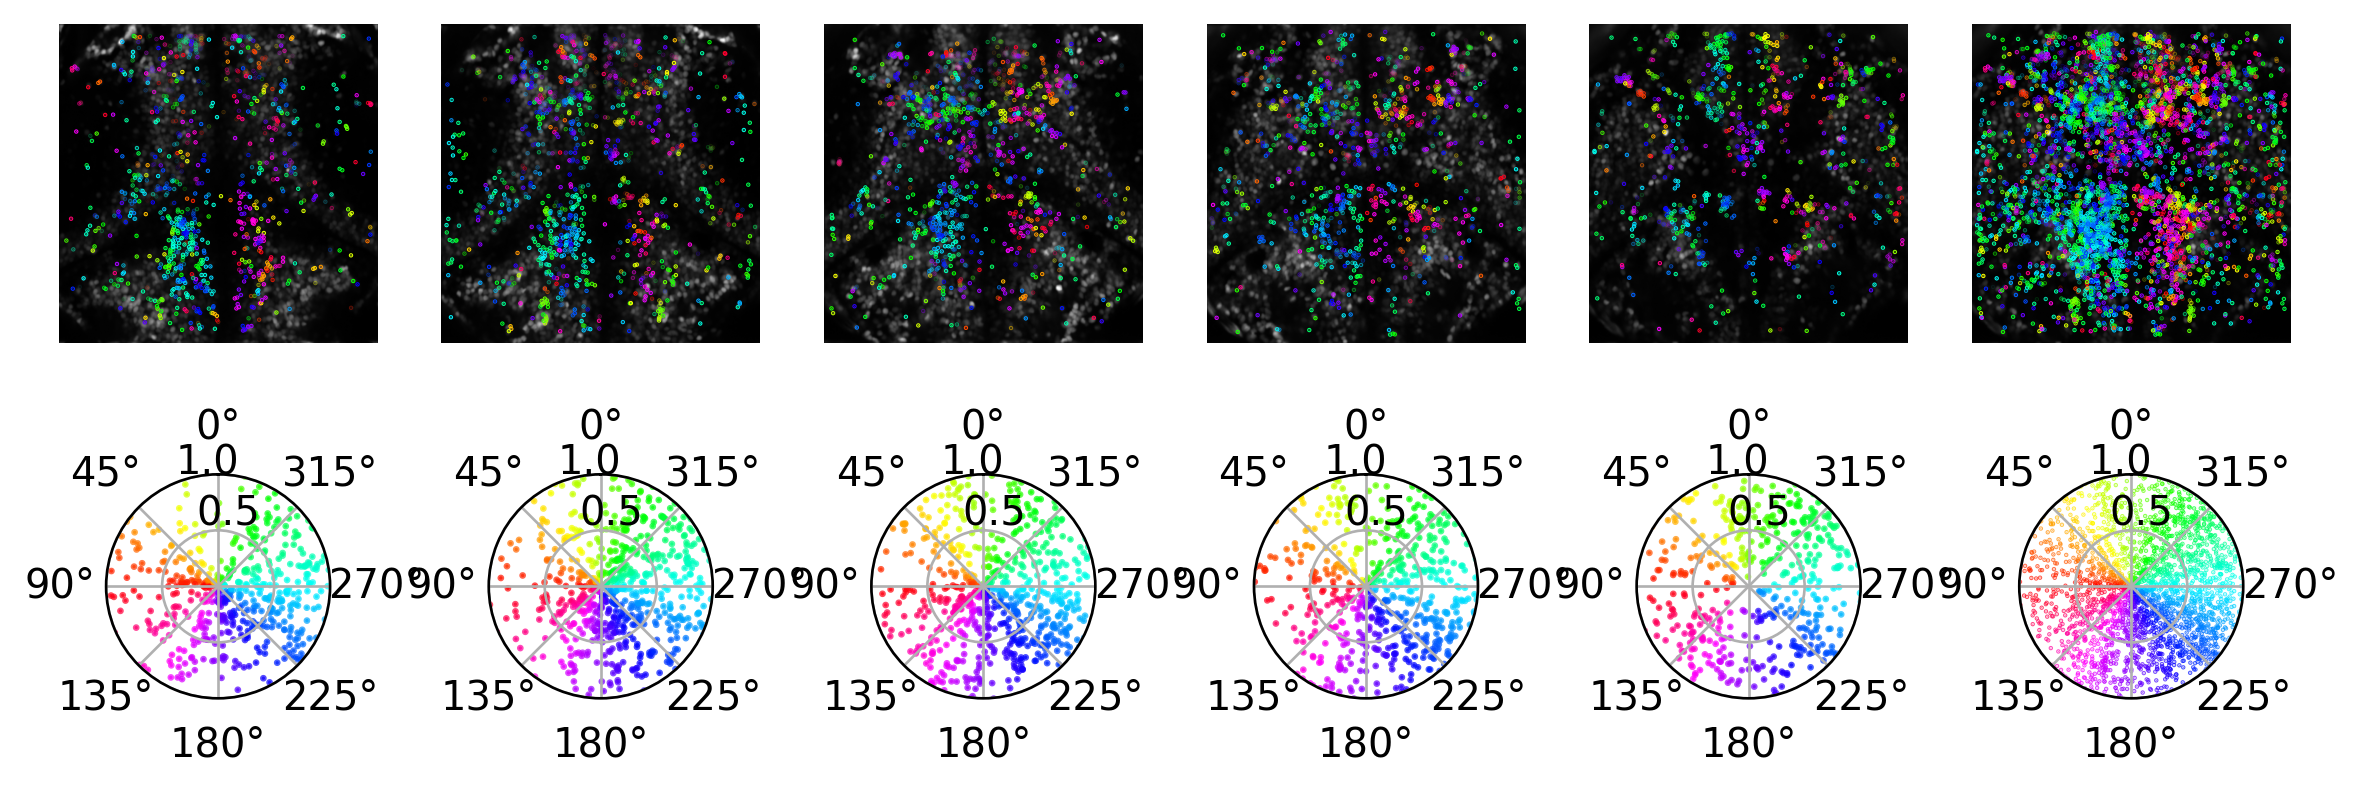

In [1407]:
barcode.plot_rainbow(fish, stim_responses)

plt.show()
plt.close()

In [ ]:
#quick run through fishes
path = r'C:\Data\Imaging\251224_overlap/fish5_HB/'
fish = Gafftopsail(path, filelist=['stimulus', 'imaging'], sequence=5)
fish.stimulus_df.stim_name = [str(s) for s in fish.stimulus_df.stim_name]

f_pertrial_dict = barcode.get_pertrial_f(fish)

barred_gratingneurons = barcode.select_gratingbarcode(fish, f_pertrial_dict, baseline_s=7, response_s=10,
                                                      perc_trial_threshold=0.8)
barred_gratingneurons = barcode.sort_gratingneurons(fish, f_pertrial_dict, barred_gratingneurons)
fig = barcode.plot_gratingneurons(fish, f_pertrial_dict, barred_gratingneurons, stim_responses=None)

for dot_stim in [None, 'dot_l', 'dot_r']:
    stim_responses = barcode.get_dsi(fish, f_pertrial_dict, baseline_s=7, response_s=6, dot_stim=dot_stim)

    for stim, neurons in barred_gratingneurons.items():
        stim_responses[f'barred_{stim}'] = stim_responses.index.isin(neurons)

    #save it
    os.makedirs(os.path.join(fish.path, "analyze_results"), exist_ok=True)
    if dot_stim is not None:
        stim_responses.to_csv(fish.path + f'//analyze_results//{dot_stim}grating_responses_delayed.csv')
    else:
        stim_responses.to_csv(fish.path + f'//analyze_results//grating_responses_delayed.csv')
    barcode.plot_rainbow(fish, stim_responses)

    plt.show()
    plt.close()

__Look at response during overlap__

In [1455]:
#look at vis responsive cells
region_list = ['all']#[['prosencephalon_(forebrain)', 'mesencephalon_(midbrain)'], 'rhombencephalon_(hindbrain)']

#get traces
f_dict = {'all':{}}#{'forebrain':{}, 'hindbrain':{}}

fig, ax = plt.subplots(len(barred_gratingneurons), 1 + 2 * len(region_list), figsize = (20, 20))
#each direction: line vs dot line
for s, stim in enumerate(barred_gratingneurons):
    stim_n = set(barred_gratingneurons[stim])
    #DSI selection
    highDSI = True
    if highDSI:
        DSI_boundary = 0.5
        angle_boundary = 45
    else:
        DSI_boundary = 0
        angle_boundary = 1000
    dsi_n = set(stim_responses[(stim_responses['DSI2'] > DSI_boundary) &
                               (np.abs((stim_responses['dir'] - utils.omr_angles[stim] + 180) % 360 - 180) <= angle_boundary)].index)
    print(f"DSI > {DSI_boundary}, angle within +/-{angle_boundary}deg")
    ax_imshow = ax[s, 0]
    ax_imshow.imshow(fish.img_dict[2], origin = 'lower')
    ax_imshow.set_axis_off()
    for r, (region, region_c) in enumerate(zip(region_list, [utils.omr_colors[stim], 'white'])):
        ax_line = ax[s, r * 2 + 1]
        ax_heat = ax[s, r * 2 + 2]
        if type(region) == list:
            region_n = set(fish.pos_all.index)#set(fish.apos_all.index[fish.apos_all['regions'].apply(lambda x: any(ri in x for ri in region))])#set(fish.apos_all.index)#
        else:
            region_n = set(fish.pos_all.index)#set(fish.apos_all.index[fish.apos_all['regions'].apply(lambda x: region in x)])
        region_n = list(region_n & stim_n & dsi_n)

        for dot_stim_n, (dot_stim, c) in enumerate(zip([None, 'dot_l', 'dot_r'], [utils.omr_colors[stim], 'slateblue', 'mediumvioletred'])):
            opp_stim = utils.angles_omr[(utils.omr_angles[stim] + 180)%360]
            if dot_stim is not None and dot_stim != 'blah':
                real_stim = str([dot_stim, stim])
                save_stim = real_stim
            elif dot_stim == 'blah':
                real_stim = opp_stim
                save_stim = real_stim + '_opp'
            else:
                real_stim = stim
                save_stim = real_stim
            #get fluorscnece
            f_acrosstrial = f_pertrial_dict[real_stim][:, region_n].mean(axis = 0)
            f_mean = f_acrosstrial.mean(axis = 0)
            f_sem = f_acrosstrial.std(axis=0) / np.sqrt(f_acrosstrial.shape[0])

            #start plotting
            ax_imshow.scatter(fish.pos_all.loc[region_n, 'xpos'], fish.pos_all.loc[region_n, 'ypos'], marker = ',', s = 1, color = region_c)

            ax_line.plot(f_mean, c=c)
            f_dict['all'][save_stim] = f_mean
            # if type(region) == list:
            #     f_dict['forebrain'][save_stim] = f_mean
            # elif type(region) != list:
            #     f_dict['hindbrain'][save_stim] = f_mean
            ax_line.fill_between(np.arange(len(f_mean)),f_mean - f_sem, f_mean + f_sem,color=c,alpha=0.3, linewidth = 0)
            ax_line.set_ylim([0.1, 0.6])

            ax_heat.imshow(f_acrosstrial, aspect='auto',extent=[0, len(f_mean), dot_stim_n, dot_stim_n+1],cmap='viridis', vmin = 0.2, vmax = 0.6)
            ax_heat.axhline(dot_stim_n, linestyle='--', color='white')
        ax_heat.set_ylim([0, dot_stim_n + 1])

DSI > 0.5, angle within +/-45deg
DSI > 0.5, angle within +/-45deg
DSI > 0.5, angle within +/-45deg
DSI > 0.5, angle within +/-45deg


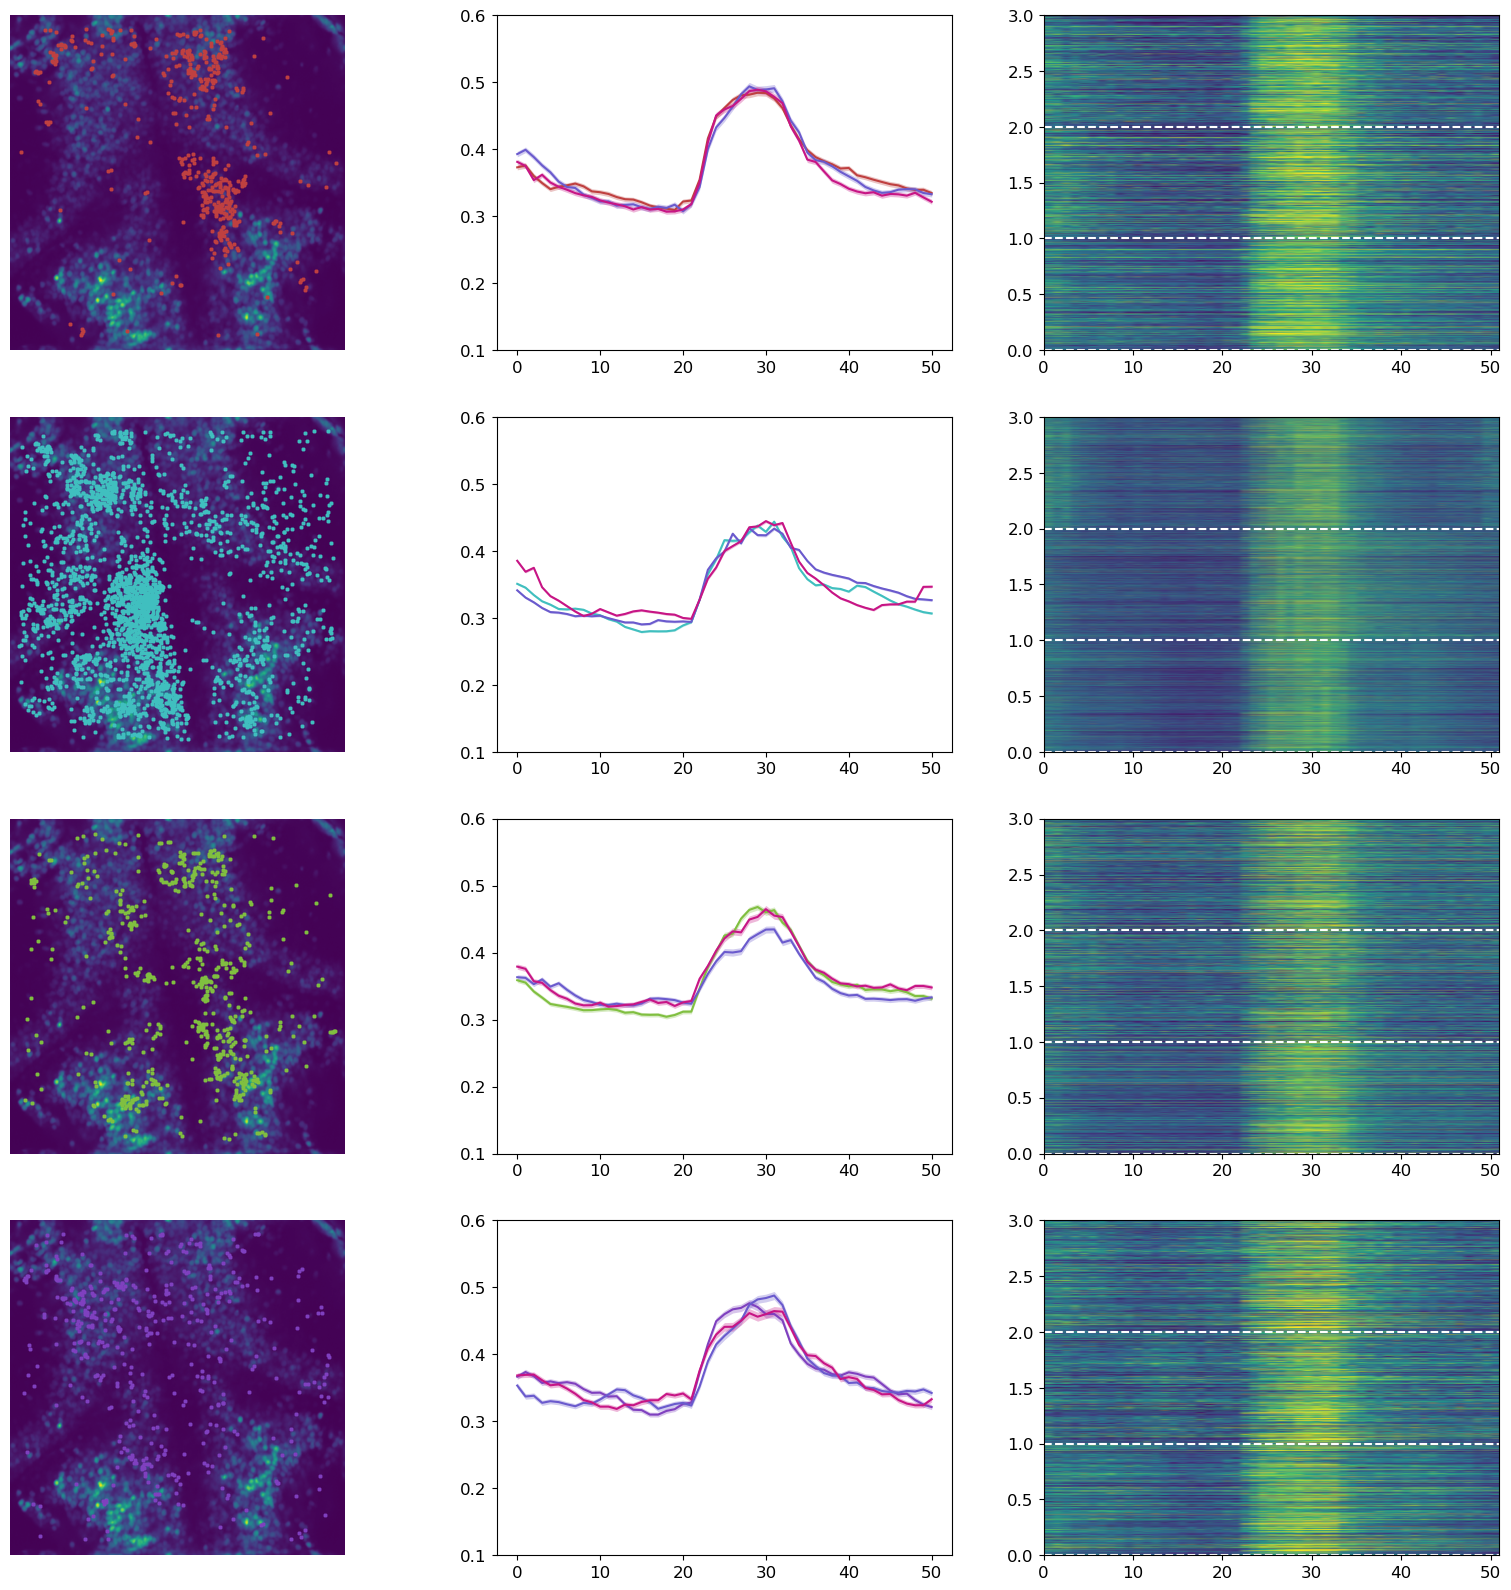

In [1456]:

if highDSI:
    # df = pd.DataFrame.from_dict(f_dict['forebrain'], orient='index')
    # df.to_csv(fish.path + "//Graphs//grating_forebrainneurons_highDSI.csv")
    # df = pd.DataFrame.from_dict(f_dict['hindbrain'], orient='index')
    # df.to_csv(fish.path + "//Graphs//grating_hindbrainneurons_highDSI.csv")
    df = pd.DataFrame.from_dict(f_dict['all'], orient='index')
    df.to_csv(fish.path + "//Graphs//grating_allneurons_highDSI.csv")
    plt.savefig(fish.path + "//Graphs//grating_neurons_highDSI.png")
else:
    # df = pd.DataFrame.from_dict(f_dict['forebrain'], orient='index')
    # df.to_csv(fish.path + "//Graphs//grating_forebrainneurons.csv")
    # df = pd.DataFrame.from_dict(f_dict['hindbrain'], orient='index')
    # df.to_csv(fish.path + "//Graphs//grating_hindbrainneurons.csv")
    df = pd.DataFrame.from_dict(f_dict['all'], orient='index')
    df.to_csv(fish.path + "//Graphs//grating_allneurons.csv")
    plt.savefig(fish.path + "//Graphs//grating_neurons.png")
plt.show()
plt.close()